# # 모델 개발 및 최적화 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 학습 데이타 : bank_churn_train.csv

[분석 요건]
- 분석 주제 : 머신러닝 기법을 활용한 은행 고객 이탈 예측 모형 최적화 실습
- 분석 단위 : 고객
- 종속 변수 : 이탈여부 (Exited)
- 설명 변수 : 고객 및 거래 정보 (성별, 연령, 계좌잔액 등)
- Data Partition : Train / Valid / Test

[주요 실습 내용]
- Feature Engineering
- Data Partition
- 모델 학습
- 모델 평가
- Hyperparameter 최적화
- Cross Validation
- 모델 해석 (SHAP)

# 데이터 준비
- 은행 이탈(Churn) 예측 모델 생성용 공개 데이터셋
- 원본 : https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling
- 교육 목적으로 원본 데이터를 일부 변형 시킴
- 변수 설명

| 변수명 | 의미 | 비고 |
|--------|------|------|
| CustomerId | 고객 고유 ID | |
| Surname | 성 | |
| CreditScore | 신용 점수 | |
| Geography | 국가 | |
| Gender | 성별 | |
| Age | 나이 | |
| Balance | 계좌 잔액 | |
| NumOfProducts | 이용 상품 수 | |
| HasCrCard | 신용카드 보유 여부 | |
| IsActiveMember | 활동 회원 여부 | |
| EstimatedSalary | 추정 연봉 | |
| Exited | 이탈 여부 (1=이탈, 0=유지) | **종속변수 (Target)** |
| baseDate | 기준일자 | |
| accountOpeningDate | 계좌개설일자 | |

데이타 불러오기

In [1]:
import pandas as pd

df = pd.read_csv("bank_churn_train.csv", encoding="cp949")

데이터 조회하기

In [2]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,baseDate,accountOpeningDate
0,15649487,Sal,578,Germany,Female,38,113150.44,2,1,0,176712.59,1,2/1/2026,4/6/2021
1,15694272,Nkemakolam,673,France,Male,30,64097.75,1,1,1,77783.35,0,2/1/2026,11/28/2024
2,15805955,L?,638,France,Female,48,138333.03,1,1,1,NaN,0,2/1/2026,12/8/2015
3,15676242,Artemova,632,Spain,Male,31,136556.44,1,1,0,82152.83,1,2/1/2026,5/2/2022
4,15756820,Fleming,655,France,Female,26,106198.50,1,0,1,32020.42,0,2/1/2026,10/30/2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,15671209,Holden,593,Germany,Female,29,101713.84,3,1,0,134594.99,0,2/1/2026,3/3/2020
2096,15721426,Milne,606,Germany,Male,65,126306.64,3,0,0,7861.68,1,2/1/2026,2/13/2015
2097,15645543,Bell,636,France,Female,34,0.00,2,1,1,44756.25,0,2/1/2026,8/3/2022
2098,15789955,Hu,698,Germany,Male,56,112414.81,2,0,0,93982.02,1,2/1/2026,7/22/2024


불필요 변수 제거

In [3]:
df = df.drop(columns=["Surname"])

컬럼정보 확인


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          2100 non-null   int64  
 1   CreditScore         2100 non-null   int64  
 2   Geography           2058 non-null   str    
 3   Gender              2100 non-null   str    
 4   Age                 2100 non-null   int64  
 5   Balance             2100 non-null   float64
 6   NumOfProducts       2100 non-null   int64  
 7   HasCrCard           2100 non-null   int64  
 8   IsActiveMember      2100 non-null   int64  
 9   EstimatedSalary     2031 non-null   float64
 10  Exited              2100 non-null   int64  
 11  baseDate            2100 non-null   str    
 12  accountOpeningDate  2100 non-null   str    
dtypes: float64(2), int64(7), str(4)
memory usage: 270.6 KB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형

컬럼타입 변경

In [5]:
df["baseDate"] = pd.to_datetime(df["baseDate"])                       # 문자열 -> 날짜 type으로 변환
df["accountOpeningDate"] = pd.to_datetime(df["accountOpeningDate"])   # 문자열 -> 날짜 type으로 변환

컬럼타입 재확인

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerId          2100 non-null   int64         
 1   CreditScore         2100 non-null   int64         
 2   Geography           2058 non-null   str           
 3   Gender              2100 non-null   str           
 4   Age                 2100 non-null   int64         
 5   Balance             2100 non-null   float64       
 6   NumOfProducts       2100 non-null   int64         
 7   HasCrCard           2100 non-null   int64         
 8   IsActiveMember      2100 non-null   int64         
 9   EstimatedSalary     2031 non-null   float64       
 10  Exited              2100 non-null   int64         
 11  baseDate            2100 non-null   datetime64[us]
 12  accountOpeningDate  2100 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(7), str(2)
memory u

# Feature Creation
- 파생변수 생성

In [7]:
import pandas as pd
import numpy as np

# 가입기간(일수) 계산
df['accountDuration_days'] = (df['baseDate'] - df['accountOpeningDate']).dt.days

# 연령대비 연봉 생성
df['salaryPerAge'] = np.where(df['Age'] > 0, df['EstimatedSalary'] / df['Age'], np.nan)

- 불필요 변수 제거

In [8]:
df = df.drop(columns=["baseDate", "accountOpeningDate"])

### [Self-Practice]

- 실습 주제 : 생성형 AI 에게 데이터 정보를 제공하고 파생변수 추천 요청하기
- 실습 조건
  - 위 df.info() 결과에서 컬럼 정보를 Copy 해서 생성형 AI 에게 input 으로 제공  
- 실습 시나리오
   - 시나리오 1) 생성형 AI 에게 파생변수 추천 요청하기
   - 시나리오 2) 생성형 AI가 추천한 변수 의미 파악하기

# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [9]:
import numpy as np

# 연속형 변수 분포 확인
df.select_dtypes(include=[np.number]).describe()

,CustomerId,CreditScore,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,accountDuration_days,salaryPerAge
count,2.100000e+03,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2031.000000,2100.000000,2100.000000,2031.000000
mean,1.568984e+07,649.784762,38.813333,76605.061957,1.536667,0.715238,0.514286,100611.165101,0.213333,2024.007143,2783.047924
std,7.211313e+04,96.818063,10.231034,62865.409749,0.591417,0.451408,0.499915,57715.705901,0.409759,1059.597137,1816.906434
min,1.556570e+07,350.000000,18.000000,0.000000,1.000000,0.000000,0.000000,216.270000,0.000000,1.000000,5.691316
25%,1.562694e+07,580.000000,32.000000,0.000000,1.000000,0.000000,0.000000,51680.575000,0.000000,1118.250000,1341.786501
50%,1.568962e+07,652.000000,37.000000,97535.745000,1.000000,1.000000,1.000000,101057.950000,0.000000,2009.000000,2579.445349
75%,1.575285e+07,717.000000,44.000000,128738.242500,2.000000,1.000000,1.000000,149756.130000,0.000000,2937.500000,3956.755354
max,1.581556e+07,850.000000,88.000000,250898.090000,4.000000,1.000000,1.000000,199857.470000,1.000000,4014.000000,10962.340556


범주형 변수 분포 확인
 - 비즈니스관점에서 데이터 이상여부 확인
 - Missing 건수 확인
 - 데이터 밀집도 확인
 - 범주 갯수 확인

In [10]:
# 범주형 변수 자동 추출
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 범주 건수 & 비율 계산
for col in cat_cols:
    print(f"\n[{col}]")
    dist = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({
        "count": dist,
        "ratio_%": ratio.round(2)
    })
    print(result)


[Geography]
           count  ratio_%
Geography                
France      1028    48.95
Spain        528    25.14
Germany      502    23.90
NaN           42     2.00

[Gender]
        count  ratio_%
Gender                
Male     1116    53.14
Female    984    46.86


/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_1784/2971682825.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


# 데이타 분할
Data Partition
 - Random Split
   - Train  : Valid : Test 비율 (6 : 2 : 2)

In [11]:
from sklearn.model_selection import train_test_split

# 1단계: train 60% / (valid + test) 40%
df_train, temp = train_test_split(df, test_size=0.4, random_state=42)

# 2단계: temp를 valid 50% / test 50% → 전체 기준 각 20%
df_valid, df_test = train_test_split(temp, test_size=0.5, random_state=42)

원본 데이터 복제

In [12]:
df_train_raw = df_train.copy()
df_valid_raw  = df_valid.copy()
df_test_raw  = df_test.copy()

분석 변수 선택

In [13]:
df_train = df_train.drop(columns=["CustomerId"])
df_valid = df_valid.drop(columns=["CustomerId"])
df_test = df_test.drop(columns=["CustomerId"])

X, Y 분리

In [14]:
# Train
X_train = df_train.drop('Exited', axis=1)
Y_train = df_train['Exited']

# Valid
X_valid = df_valid.drop('Exited', axis=1)
Y_valid = df_valid['Exited']

# Test
X_test = df_test.drop('Exited', axis=1)
Y_test = df_test['Exited']

# Feature Transformation


Missing 처리

- Missing 데이터 확인

In [15]:
# X 변수
X_train.isna().sum()

CreditScore              0
Geography               25
Gender                   0
Age                      0
Balance                  0
NumOfProducts            0
HasCrCard                0
IsActiveMember           0
EstimatedSalary         47
accountDuration_days     0
salaryPerAge            47
dtype: int64

In [16]:
# Y 변수 -> Missing 있는 경우 Data Partition 이전 단계에서 삭제 필요
Y_train.isna().sum()

np.int64(0)

- 연속형 변수 대체 : Median


In [17]:
import numpy as np
import pandas as pd

# 연속형 변수 추출
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# X_train에서 중앙값 계산
medians = X_train[num_cols].median()

# Missing 값을 중앙값으로 대체
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_valid[num_cols] = X_valid[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

   - 범주형 변수 대체 : New class ('Unknown')

In [18]:
# 신규 범주 (Unknown) 로 대체
import pandas as pd

# 범주형 변수 추출 (object + category)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    # category 타입이면 Unknown 먼저 추가
    if X_train[col].dtype.name == 'category':
        X_train[col] = X_train[col].cat.add_categories('Unknown')
        X_valid[col] = X_valid[col].cat.add_categories('Unknown')
        X_test[col] = X_test[col].cat.add_categories('Unknown')

    # Missing → 'Unknown'
    X_train[col] = X_train[col].fillna('Unknown')
    X_valid[col] = X_valid[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_1784/546292776.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


- Missing 데이터 재확인

In [19]:
X_train.isnull().sum()

CreditScore             0
Geography               0
Gender                  0
Age                     0
Balance                 0
NumOfProducts           0
HasCrCard               0
IsActiveMember          0
EstimatedSalary         0
accountDuration_days    0
salaryPerAge            0
dtype: int64

분포 변환
- 로그 변환

In [20]:
import pandas as pd
import numpy as np

# ==========================================
# 변수 분리
# ==========================================

# 연속형 변수 추출
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 범주형 변수 추출
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


# ==========================================
# Log Transformation 함수 정의
# ==========================================

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


# ==========================================
# Train, Valid, Test 데이터 변환 적용
# ==========================================

# Train 연속형 변수 변환
train_log = X_train[num_cols].apply(signed_log1p)

# Valid 연속형 변수 변환
valid_log = X_valid[num_cols].apply(signed_log1p)

# Test 연속형 변수 변환
test_log = X_test[num_cols].apply(signed_log1p)


# ==========================================
# 데이터 병합 (변환된 변수 + 범주형)
# ==========================================

# X_train
X_train = pd.concat(
    [
        train_log,                # Log 변환된 연속형 변수들
        X_train[cat_cols]         # 범주형 변수들
    ],
    axis=1
)

# X_valid
X_valid = pd.concat(
    [
        valid_log,                # Log 변환된 연속형 변수들
        X_valid[cat_cols]         # 범주형 변수들
    ],
    axis=1
)

# X_test
X_test = pd.concat(
    [
        test_log,                 # Log 변환된 연속형 변수들
        X_test[cat_cols]          # 범주형 변수들
    ],
    axis=1
)

/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_1784/720988127.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


데이터 Scaling
 - Min-Max 변환


In [21]:
from sklearn.preprocessing import MinMaxScaler

# 연속형 / 범주형 구분
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Min-Max Scaler (Train에서만 fit)
scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# 연속형 + 범주형 병합
X_train = pd.concat([X_train[num_cols], X_train[cat_cols]], axis=1)
X_valid = pd.concat([X_valid[num_cols], X_valid[cat_cols]], axis=1)
X_test  = pd.concat([X_test[num_cols],  X_test[cat_cols]], axis=1)

/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_1784/2911694055.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


범주형 변수 인코딩
- 범주형 변수 범주 개수 확인

In [22]:
# 범주형 변수 자동 식별
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n[문자형 컬럼]:", cat_cols)

# 각 변수의 고유값 개수
print("\n[변수별 범주 개수]")
for col in cat_cols:
    n_unique = X_train[col].nunique()
    print(f"  {col}: {n_unique}개")


[문자형 컬럼]: ['Geography', 'Gender']

[변수별 범주 개수]
  Geography: 4개
  Gender: 2개


/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_1784/258138321.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


- One-Hot Encoding : 범주 개수가 많지 않은 경우

In [23]:
import pandas as pd

# 범주형 컬럼 선택 (train 기준)
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=False, dummy_na=False)
X_valid = pd.get_dummies(X_valid, drop_first=False, dummy_na=False)
X_test  = pd.get_dummies(X_test,  drop_first=False, dummy_na=False)

# valid/test 를 train 컬럼 구조에 맞추기
#    - train에 있고, valid/test에 없는 컬럼 → 0으로 채움
#    - train에 없고, valid/test에 있는 컬럼 → 제거
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)
X_test  = X_test.reindex(columns=X_train.columns,  fill_value=0)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (1260, 15)
X_valid shape: (420, 15)
X_test  shape: (420, 15)


/var/folders/14/gczk6h2n7nb_w800tdh9mtb40000gn/T/ipykernel_1784/2967721449.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


# Feature Selection
- 일반적으로 파생변수 생성 -> 데이타 분할 -> 데이타 변환 (Feature Transformation) -> Feature Selection 순으로 진행

Feature 신뢰성 검증
- 단일값 변수 제거

In [24]:
# 고유값 개수 계산 (NaN 포함)
unique_counts = X_train.nunique(dropna=False)

# 고유값이 1개 이하인 컬럼 식별
cols_to_drop = unique_counts[unique_counts <= 1].index.tolist()

# 데이터셋에서 삭제
X_train = X_train.drop(columns=cols_to_drop)
X_valid = X_valid.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"삭제된 컬럼: {cols_to_drop}")

삭제된 컬럼: []


- 상관 분석 : 변수간 중복성 검증 목적
  - 설명변수간 상관계수 산출

In [25]:
import numpy as np
import pandas as pd

# 연속형 변수 컬럼 감지
continuous_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 상관행렬 계산
corr_matrix = X_train[continuous_cols].corr()

# 상삼각(Upper Triangle) 행렬의 인덱스 추출 (대각선 제외, 중복 제거)
upper_idx = np.triu_indices_from(corr_matrix, k=1)

# 변수1, 변수2, 상관계수 형태의 DataFrame 생성
corr_df = pd.DataFrame({
    '변수1': corr_matrix.columns[upper_idx[0]],
    '변수2': corr_matrix.columns[upper_idx[1]],
    '상관계수': corr_matrix.values[upper_idx]
})

# 상관계수 절대값 기준 내림차순 정렬
corr_df = corr_df.reindex(corr_df['상관계수'].abs().sort_values(ascending=False).index)

# 결과 출력
print("=== 연속형 변수 상관분석 (상관계수 높은 순) ===")
print(corr_df.to_string(index=False))

=== 연속형 변수 상관분석 (상관계수 높은 순) ===
                 변수1                  변수2      상관계수
     EstimatedSalary         salaryPerAge  0.968967
             Balance        NumOfProducts -0.351326
                 Age         salaryPerAge -0.242409
                 Age       IsActiveMember  0.089277
             Balance accountDuration_days -0.056657
      IsActiveMember accountDuration_days -0.056271
                 Age        NumOfProducts -0.055577
       NumOfProducts         salaryPerAge  0.050951
             Balance         salaryPerAge -0.048125
             Balance      EstimatedSalary -0.044273
       NumOfProducts      EstimatedSalary  0.038373
       NumOfProducts accountDuration_days  0.036890
         CreditScore                  Age -0.035970
         CreditScore            HasCrCard  0.032252
      IsActiveMember         salaryPerAge -0.031390
       NumOfProducts            HasCrCard -0.028949
         CreditScore accountDuration_days  0.028941
         CreditScore        NumO

- 상관계수 높은 변수 제거

In [26]:
import numpy as np
import pandas as pd

# 연속형/범주형 컬럼 구분
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("최초 X변수 수:", X_train.shape[1])

# Train 기준 상관분석 → 제거할 변수 선정
corr = X_train[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# 상관계수 임계값
threshold = 1.0   # max: 1.0
to_drop = [col for col in upper.columns if (upper[col] >= threshold).any()]

print("제거된 연속형 변수 리스트:")
print(to_drop)

# Train/Valid/Test 동일하게 제거
X_train = X_train.drop(columns=to_drop, errors="ignore")
X_valid = X_valid.drop(columns=to_drop, errors="ignore")
X_test = X_test.drop(columns=to_drop, errors="ignore")

print("제거 후 X변수 수:", X_train.shape[1])

최초 X변수 수: 15
제거된 연속형 변수 리스트:
[]
제거 후 X변수 수: 15


### [Quiz]

Q1) 설명변수간 중복성 문제로 상관성 높은 변수를 제거할때 상관성 높음의 기준은? 0.80, 0.90, 0.95...??

- 기준은 없다. 해보고  성능이 좋으면 좋은거

Q2) 결측치 처리, 로그 변환, Scaling 등 Feature 변환 판단 기준은?

- 성능

Feature 중요도 검증
- Feature Importance 분석 : Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

# RandomForest 모델 학습
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, Y_train)

# Feature Importance 추출
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n[Random Forest 기준 Feature Importance]")
print(importance_df.to_string(index=False))

print("\n[총 feature 갯수]", len(X_train.columns))


[Random Forest 기준 Feature Importance]
             feature  importance
                 Age    0.201513
       NumOfProducts    0.128118
        salaryPerAge    0.112195
         CreditScore    0.112036
     EstimatedSalary    0.108770
accountDuration_days    0.102049
             Balance    0.089515
      IsActiveMember    0.054900
           HasCrCard    0.017077
   Geography_Germany    0.016652
    Geography_France    0.013919
     Geography_Spain    0.013230
         Gender_Male    0.013130
       Gender_Female    0.012631
   Geography_Unknown    0.004265

[총 feature 갯수] 15


- Feature Importance 기반 변수 선택

In [28]:
# 중요도 상위 Feature 선택

print("\n[총 feature 갯수]")
max_features = len(X_train.columns)
print(f"개수: {max_features}")

TOP_N = max_features    # 원하는 상위 Feature 개수로 변경, 선택 안할 경우: max_features
final_features = importance_df.loc[:TOP_N-1, "feature"].tolist()

print(f"\n[최종 선택 변수]")
print(f"개수: {len(final_features)}")
print(f"변수: {final_features}")

# 최종 X 데이타
X_train = X_train[final_features]
X_valid = X_valid[final_features]
X_test = X_test[final_features]


[총 feature 갯수]
개수: 15

[최종 선택 변수]
개수: 15
변수: ['Age', 'NumOfProducts', 'salaryPerAge', 'CreditScore', 'EstimatedSalary', 'accountDuration_days', 'Balance', 'IsActiveMember', 'HasCrCard', 'Geography_Germany', 'Geography_France', 'Geography_Spain', 'Gender_Male', 'Gender_Female', 'Geography_Unknown']


### [Quiz]

Q1) Feature Importance 기준 Feature 선택 이유는?   
Q2) Feature Importance 기준 Feature 선택 시 Feature 적정 개수는?

PCA
- 차원의 저주 문제 발생시 차원 축소
- 차원 축소 이후에는 개별 변수 해석이 어려움

In [ ]:
'''
from sklearn.decomposition import PCA
import numpy as np

# PCA 학습 (train 기준)
# 누적 설명분산 90%를 유지하도록 차원 자동 선택 (전체 정보의 90%를 설명)
pca = PCA(n_components=0.90, random_state=42)  # 변수 개수 지정시 정수값 입력, ex) n_components=10

X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca  = pca.transform(X_test)

print("선택된 주성분 개수:", pca.n_components_)

# DataFrame으로 변환
pc_cols = [f"PC{i+1}" for i in range(pca.n_components_)]

X_train = pd.DataFrame(X_train_pca, index=X_train.index, columns=pc_cols)
X_valid = pd.DataFrame(X_valid_pca, index=X_valid.index, columns=pc_cols)
X_test  = pd.DataFrame(X_test_pca,  index=X_test.index,  columns=pc_cols)

print(X_train.shape, X_valid.shape, X_test.shape)
'''

# Decision Tree
  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

 학습 및 평가

In [29]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score)

# 모델 생성
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)
model.fit(X_train, Y_train)

# X_valid 예측
Y_valid_pred = model.predict(X_valid)
Y_valid_prob = model.predict_proba(X_valid)[:, 1]  # AUC용 확률값

# X_test 예측
Y_test_pred = model.predict(X_test)
Y_test_prob = model.predict_proba(X_test)[:, 1]    # AUC용 확률값

# 평가 함수 정의
def evaluate(Y_actual, Y_pred, Y_prob, dataset_name):
    accuracy  = accuracy_score(Y_actual, Y_pred)
    f1        = f1_score(Y_actual, Y_pred)
    recall    = recall_score(Y_actual, Y_pred)
    precision = precision_score(Y_actual, Y_pred)
    auc       = roc_auc_score(Y_actual, Y_prob)

    print(f"\n=== {dataset_name} 평가 ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {'Accuracy': accuracy, 'F1': f1, 'Recall': recall,
            'Precision': precision, 'AUC': auc}

# Validation, Test 평가 실행
valid_scores = evaluate(Y_valid, Y_valid_pred, Y_valid_prob, "Validation")
test_scores  = evaluate(Y_test,  Y_test_pred,  Y_test_prob,  "Test")


=== Validation 평가 ===
Accuracy : 0.7833
F1 Score : 0.5285
Recall   : 0.4811
Precision: 0.5862
AUC      : 0.7820

=== Test 평가 ===
Accuracy : 0.8476
F1 Score : 0.4754
Recall   : 0.4265
Precision: 0.5370
AUC      : 0.7624


Tree 시각화
  - 노드 비율 기준 출력

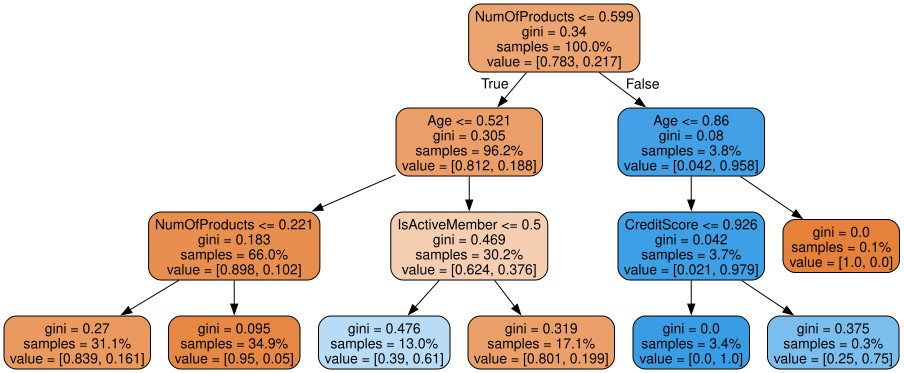

In [30]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    filled=True,
    proportion=True,  # 비율 표시
    rounded=True
)

graphviz.Source(dot_data)

원래 데이터에 예측값 병합하기
 - 동일 노드내에서는 동일 예측값 확인
 - 예측값 의미 확인 -> 노드내 Positive class 비율

In [31]:
df_test_raw["y_pred"] = Y_test_prob
df_test_raw

,CustomerId,CreditScore,Geography,Gender,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,accountDuration_days,salaryPerAge,y_pred
764,15686870,761,Germany,Male,36,108239.11,2,0,0,99444.02,0,3003,2762.333889,0.050000
1112,15762803,509,France,Male,31,0.00,2,1,0,15360.91,0,1270,495.513226,0.050000
51,15698619,593,France,Male,43,0.00,2,1,1,76357.43,0,3507,1775.754186,0.199074
1831,15796969,731,France,Male,33,0.00,2,1,1,NaN,0,1803,NaN,0.050000
1964,15619029,620,Spain,Female,43,0.00,2,1,0,20670.10,0,779,480.700000,0.609756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779,15696674,643,Germany,Female,45,150842.93,1,0,1,2319.96,1,906,51.554667,0.199074
1075,15570943,711,Germany,Female,35,133607.75,1,1,1,120586.32,0,1034,3445.323429,0.160714
2038,15592386,520,France,Male,58,0.00,2,0,1,32790.02,0,1383,565.345172,0.199074
222,15695846,684,France,Female,34,0.00,2,1,1,130928.22,0,2419,3850.830000,0.050000


### [Self-Practice]

Q1) 이탈이 가장 높은 집단과 가장 낮은 집단 (노드)의 규칙(Rule)을 각각 도출하고, 두 집단의 특성 차이를 비교하세요. 단, Log 변환, Scaling 을 적용하지 않은 상태에서 분석하세요.

# Baseline 모델 평가
 - Naive Baseline  *가장 단순하고 직관적인 방법으로 만든 모델

In [32]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score)

# Y_train에서 가장 많은 범주(최다수 클래스) 및 비율 확인
y_train_counts = pd.Series(Y_train).value_counts()
majority_class = y_train_counts.index[0]               # 최다수 클래스
majority_ratio = y_train_counts.iloc[0] / len(Y_train) # 최다수 클래스 비율

print("=== Y_train 범주 비율 ===")
print(y_train_counts)
print(f"\n최다수 클래스: {majority_class}")
print(f"최다수 클래스 비율: {majority_ratio:.4f} ({majority_ratio * 100:.2f}%)")

# 최다수 클래스로 Test Set 예측
Y_test_pred = np.full(len(Y_test), majority_class)          # 전체를 최다수 클래스로 예측
Y_test_prob = np.full(len(Y_test), 1 - majority_ratio)      # 예측 확률은 (1 - 최다수 클래스 비율)

# Test Set 평가
accuracy  = accuracy_score(Y_test, Y_test_pred)
f1        = f1_score(Y_test, Y_test_pred)
recall    = recall_score(Y_test, Y_test_pred)
precision = precision_score(Y_test, Y_test_pred)
auc       = roc_auc_score(Y_test, Y_test_prob)

print(f"\n=== Test 평가 (Baseline) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC      : {auc:.4f}")

=== Y_train 범주 비율 ===
Exited
0    986
1    274
Name: count, dtype: int64

최다수 클래스: 0
최다수 클래스 비율: 0.7825 (78.25%)

=== Test 평가 (Baseline) ===
Accuracy : 0.8381
F1 Score : 0.0000
Recall   : 0.0000
Precision: 0.0000
AUC      : 0.5000


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# RandomForest

  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

 학습 및 평가

In [33]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score)

# 모델 생성
model = RandomForestClassifier(
    n_estimators=100,         # 트리 수
    max_depth=10,             # 트리 깊이 제한
    class_weight="balanced",  # 불균형일 때 소수 클래스에 가중치를 더 부여
    min_samples_split=10,     # 분할 최소 샘플 수
    min_samples_leaf=5,       # 리프 노드 최소 샘플 수
    random_state=42           # 난수 시드를 고정
)

model.fit(X_train, Y_train)

# X_valid 예측
Y_valid_pred = model.predict(X_valid)
Y_valid_prob = model.predict_proba(X_valid)[:, 1]  # AUC용 확률값

# X_test 예측
Y_test_pred = model.predict(X_test)
Y_test_prob = model.predict_proba(X_test)[:, 1]    # AUC용 확률값

# 평가 함수 정의
def evaluate(Y_actual, Y_pred, Y_prob, dataset_name):
    accuracy  = accuracy_score(Y_actual, Y_pred)
    f1        = f1_score(Y_actual, Y_pred)
    recall    = recall_score(Y_actual, Y_pred)
    precision = precision_score(Y_actual, Y_pred)
    auc       = roc_auc_score(Y_actual, Y_prob)

    print(f"\n=== {dataset_name} 평가 ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {'Accuracy': accuracy, 'F1': f1, 'Recall': recall,
            'Precision': precision, 'AUC': auc}

# Validation, Test 평가 실행
valid_scores = evaluate(Y_valid, Y_valid_pred, Y_valid_prob, "Validation")
test_scores  = evaluate(Y_test,  Y_test_pred,  Y_test_prob,  "Test")


=== Validation 평가 ===
Accuracy : 0.7952
F1 Score : 0.6356
Recall   : 0.7075
Precision: 0.5769
AUC      : 0.8446

=== Test 평가 ===
Accuracy : 0.8262
F1 Score : 0.5229
Recall   : 0.5882
Precision: 0.4706
AUC      : 0.8399


### [Self-Practice]

Q1) RandomForest 모델의 하이퍼파라미터를 수동으로 조정하면서 모델 성능 변화를 비교해 보세요.  
Q2) RandomForest 외 다른 ML 모델(XGBoost, LightGBM 등)을 적용하여 성능을 비교해 보세요.

# Hyperparameter 최적화
 - Cross Validation (CV) 방식 : Stratified K-Fold 적용, https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
 - Data Partition : Train (CV), Valid, Test

Bayesian Search
- API 문서 : https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html
- RandomForest 모델 최적화

In [36]:
!pip install scikit-optimize

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    TimeSeriesSplit
)
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
)

# ==========================================
# 기본 모델 설정 : 기본 설정 (튜닝이 필요 없는 운영·재현성 관련 값)
# ==========================================

model = RandomForestClassifier(
    random_state=42,         # 난수 시드 고정
    n_jobs=-1,               # 모든 CPU 코어 사용
    class_weight="balanced"  # 불균형일 때 소수 클래스에 가중치를 더 부여
)


# ==========================================
# 탐색 공간 정의 : 튜닝 대상 설정 (필요에 맞게 조정)
# ==========================================

search_space = {
    "n_estimators": Integer(100, 500),               # 생성할 Tree 개수, 100 ≤ 값 ≤ 500 에서 최적값 탐색
    "max_depth": Integer(2, 20),                     # Tree 최대 깊이
    "min_samples_split": Integer(2, 30),             # 노드를 분할하기 위한 최소 샘플 수
    "min_samples_leaf": Integer(1, 20),              # Leaf에 필요한 최소 샘플 수
}


# ==========================================
# Cross Validation 정의
# ==========================================

# Stratified K-Fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)   # 분류 모델에서 클래스 비율 유지
#cv = KFold(n_splits=3, shuffle=True, random_state=42)            # 회귀 or 분류 모델에서 클래스 비율 무시
#cv = TimeSeriesSplit(n_splits=3)                                 # 시계열 데이터


# ==========================================
# Hyperparameter 최적화 학습
# ==========================================

# Bayesian Search 정의
opt = BayesSearchCV(
    estimator=model,
    search_spaces=search_space,
    n_iter=10,                 # 탐색 횟수 (늘릴수록 성능↑, 시간↑)
    scoring="roc_auc",         # 최적 모델 판단 기준 (이진분류 기준, 다중분류면: 'roc_auc_ovr')
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,                # 최적 파라미터로 전체 X_train 재학습
    verbose=0
)

# 최적화 학습
opt.fit(X_train, Y_train)

best_model = opt.best_estimator_
print(f"\n[CV Result]")
print("Best params:", opt.best_params_)
print("Best CV score:", opt.best_score_)


# ==========================================
# 예측
# ==========================================

# X_valid 예측
Y_valid_pred = best_model.predict(X_valid)
Y_valid_prob = best_model.predict_proba(X_valid)[:, 1]  # AUC용 확률값

# X_test 예측
Y_test_pred = best_model.predict(X_test)
Y_test_prob = best_model.predict_proba(X_test)[:, 1]    # AUC용 확률값


# ==========================================
# 모델 평가
# ==========================================

# 평가 함수 정의
def evaluate(Y_actual, Y_pred, Y_prob, dataset_name):
    accuracy  = accuracy_score(Y_actual, Y_pred)
    f1        = f1_score(Y_actual, Y_pred)
    recall    = recall_score(Y_actual, Y_pred)
    precision = precision_score(Y_actual, Y_pred)
    auc       = roc_auc_score(Y_actual, Y_prob)

    print(f"\n=== {dataset_name} 평가 ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {'Accuracy': accuracy, 'F1': f1, 'Recall': recall,
            'Precision': precision, 'AUC': auc}

# Validation, Test 평가 실행
valid_scores = evaluate(Y_valid, Y_valid_pred, Y_valid_prob, "Validation")
test_scores  = evaluate(Y_test,  Y_test_pred,  Y_test_prob,  "Test")


[CV Result]
Best params: OrderedDict([('max_depth', 17), ('min_samples_leaf', 4), ('min_samples_split', 19), ('n_estimators', 421)])
Best CV score: 0.8256542260856768

=== Validation 평가 ===
Accuracy : 0.7905
F1 Score : 0.6364
Recall   : 0.7264
Precision: 0.5662
AUC      : 0.8489

=== Test 평가 ===
Accuracy : 0.8333
F1 Score : 0.5333
Recall   : 0.5882
Precision: 0.4878
AUC      : 0.8370


### [Self-Practice]

Q1) 위에서 RandomForest 모델의 Hyperparameter를 수동으로 설정한 결과와 Bayesian Search 결과를 비교해 보세요.   
Q2) RandomForest 외 다른 모델 (XGBoost, LightGBM)을 기본 모델로 설정 후 Bayesian Search 결과를 비교해 보세요.

Random Search
- API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
- RandomForest 모델 최적화

In [37]:
import numpy as np
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
)

# ==========================================
# 기본 모델 설정 : 기본 설정 (튜닝이 필요 없는 운영·재현성 관련 값)
# ==========================================

model = RandomForestClassifier(
    random_state=42,         # 난수 시드 고정
    n_jobs=-1,               # 모든 CPU 코어 사용
    class_weight="balanced"  # 불균형일 때 소수 클래스에 가중치를 더 부여
)


# ==========================================
# 탐색 공간 정의 : 튜닝 대상 설정 (필요에 맞게 조정)
# ==========================================

# Randomized는 범위 or 리스트 모두 가능
search_space = {
    "n_estimators": randint(100, 500),               # 생성할 Tree 개수, randint: 100 ≤ 값 ≤ 500 에서 무작위 탐색
    "max_depth": randint(2, 20),                     # Tree 최대 깊이
    "min_samples_split": randint(2, 30),             # 노드를 분할하기 위한 최소 샘플 수
    "min_samples_leaf": randint(1, 20),              # Leaf에 필요한 최소 샘플 수
}

# ==========================================
# Cross Validation 정의
# ==========================================

# Stratified K-Fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)   # 분류 모델에서 클래스 비율 유지
#cv = KFold(n_splits=3, shuffle=True, random_state=42)            # 회귀 or 분류 모델에서 클래스 비율 무시
#cv = TimeSeriesSplit(n_splits=3)                                 # 시계열 데이터


# ==========================================
# Hyperparameter 최적화 학습
# ==========================================

# Randomized Search 정의
opt = RandomizedSearchCV(
    estimator=model,
    param_distributions=search_space,
    n_iter=10,                 # 탐색 횟수 (늘릴수록 성능↑, 시간↑)
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=0
)

# 최적화 학습
opt.fit(X_train, Y_train)

best_model = opt.best_estimator_
print(f"\n[CV Result]")
print("Best params:", opt.best_params_)
print("Best CV score:", opt.best_score_)


# ==========================================
# 예측
# ==========================================

# X_valid 예측
Y_valid_pred = best_model.predict(X_valid)
Y_valid_prob = best_model.predict_proba(X_valid)[:, 1]  # AUC용 확률값

# X_test 예측
Y_test_pred = best_model.predict(X_test)
Y_test_prob = best_model.predict_proba(X_test)[:, 1]    # AUC용 확률값


# ==========================================
# 모델 평가
# ==========================================

# 평가 함수 정의
def evaluate(Y_actual, Y_pred, Y_prob, dataset_name):
    accuracy  = accuracy_score(Y_actual, Y_pred)
    f1        = f1_score(Y_actual, Y_pred)
    recall    = recall_score(Y_actual, Y_pred)
    precision = precision_score(Y_actual, Y_pred)
    auc       = roc_auc_score(Y_actual, Y_prob)

    print(f"\n=== {dataset_name} 평가 ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {'Accuracy': accuracy, 'F1': f1, 'Recall': recall,
            'Precision': precision, 'AUC': auc}

# Validation, Test 평가 실행
valid_scores = evaluate(Y_valid, Y_valid_pred, Y_valid_prob, "Validation")
test_scores  = evaluate(Y_test,  Y_test_pred,  Y_test_prob,  "Test")


[CV Result]
Best params: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 25, 'n_estimators': 393}
Best CV score: 0.8271966297153687

=== Validation 평가 ===
Accuracy : 0.7786
F1 Score : 0.6324
Recall   : 0.7547
Precision: 0.5442
AUC      : 0.8420

=== Test 평가 ===
Accuracy : 0.7929
F1 Score : 0.4971
Recall   : 0.6324
Precision: 0.4095
AUC      : 0.8234


Grid Search
- API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- RandomForest 모델 최적화

In [38]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, KFold, TimeSeriesSplit, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
)

# ==========================================
# 기본 모델 설정 : 기본 설정 (튜닝이 필요 없는 운영·재현성 관련 값)
# ==========================================

model = RandomForestClassifier(
    random_state=42,         # 난수 시드 고정
    n_jobs=-1,               # 모든 CPU 코어 사용
    class_weight="balanced"  # 불균형일 때 소수 클래스에 가중치를 더 부여
)


# ==========================================
# 탐색 공간 정의 : 튜닝 대상 설정 (필요에 맞게 조정)
# ==========================================

# Grid는 전수 조사이므로 리스트로 지정한 값만 탐색
# 아래의 경우 2×2×2×2=16번 탐색
search_space = {
    "n_estimators": [100, 300],     # 생성할 Tree 개수, 100 과 300 만 탐색
    "max_depth": [5, 10],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 10]
}

# ==========================================
# Cross Validation 정의
# ==========================================

# Stratified K-Fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)   # 분류 모델에서 클래스 비율 유지
#cv = KFold(n_splits=3, shuffle=True, random_state=42)            # 회귀 or 분류 모델에서 클래스 비율 무시
#cv = TimeSeriesSplit(n_splits=3)                                 # 시계열 데이터


# ==========================================
# Hyperparameter 최적화 학습
# ==========================================

# Grid Search 정의, 탐색 횟수 설정이 없음
opt = GridSearchCV(
    estimator=model,
    param_grid=search_space,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)


# 최적화 학습
opt.fit(X_train, Y_train)

best_model = opt.best_estimator_
print(f"\n[CV Result]")
print("Best params:", opt.best_params_)
print("Best CV score:", opt.best_score_)


# ==========================================
# 예측
# ==========================================

# X_valid 예측
Y_valid_pred = best_model.predict(X_valid)
Y_valid_prob = best_model.predict_proba(X_valid)[:, 1]  # AUC용 확률값

# X_test 예측
Y_test_pred = best_model.predict(X_test)
Y_test_prob = best_model.predict_proba(X_test)[:, 1]    # AUC용 확률값


# ==========================================
# 모델 평가
# ==========================================

# 평가 함수 정의
def evaluate(Y_actual, Y_pred, Y_prob, dataset_name):
    accuracy  = accuracy_score(Y_actual, Y_pred)
    f1        = f1_score(Y_actual, Y_pred)
    recall    = recall_score(Y_actual, Y_pred)
    precision = precision_score(Y_actual, Y_pred)
    auc       = roc_auc_score(Y_actual, Y_prob)

    print(f"\n=== {dataset_name} 평가 ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {'Accuracy': accuracy, 'F1': f1, 'Recall': recall,
            'Precision': precision, 'AUC': auc}

# Validation, Test 평가 실행
valid_scores = evaluate(Y_valid, Y_valid_pred, Y_valid_prob, "Validation")
test_scores  = evaluate(Y_test,  Y_test_pred,  Y_test_prob,  "Test")


[CV Result]
Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV score: 0.8297360275012355

=== Validation 평가 ===
Accuracy : 0.7762
F1 Score : 0.6357
Recall   : 0.7736
Precision: 0.5395
AUC      : 0.8465

=== Test 평가 ===
Accuracy : 0.8024
F1 Score : 0.4970
Recall   : 0.6029
Precision: 0.4227
AUC      : 0.8293


# 모델 해석

최종 모델 선정

- 예) RandomForest

In [39]:
from sklearn.ensemble import RandomForestClassifier

# 모델 생성
model = RandomForestClassifier(
    n_estimators=100,         # 트리 수
    max_depth=10,             # 트리 깊이 제한
    class_weight="balanced",  # 불균형일 때 소수 클래스에 가중치를 더 부여
    min_samples_split=10,     # 분할 최소 샘플 수
    min_samples_leaf=5,       # 리프 노드 최소 샘플 수
    random_state=42           # 난수 시드를 고정
)

model.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

모델 해석 1) Feature Importance : Tree 계열의 모델인 경우   
\- 주로 학습 과정에서 Feature 중요도 파악 목적  
\- 학습 전 Feature 선정 시 or 학습 후 모델 해석 시 사용  
\- 분석 대상 데이타 : Train Set

- RandomForest 의 Feature Importance

                 Feature  Importance
0                    Age    0.279119
1          NumOfProducts    0.148646
2           salaryPerAge    0.098192
4        EstimatedSalary    0.088250
7         IsActiveMember    0.085096
3            CreditScore    0.079890
6                Balance    0.070089
5   accountDuration_days    0.066662
13         Gender_Female    0.017838
12           Gender_Male    0.017212
9      Geography_Germany    0.015477
10      Geography_France    0.013226
11       Geography_Spain    0.010710
8              HasCrCard    0.009236
14     Geography_Unknown    0.000357


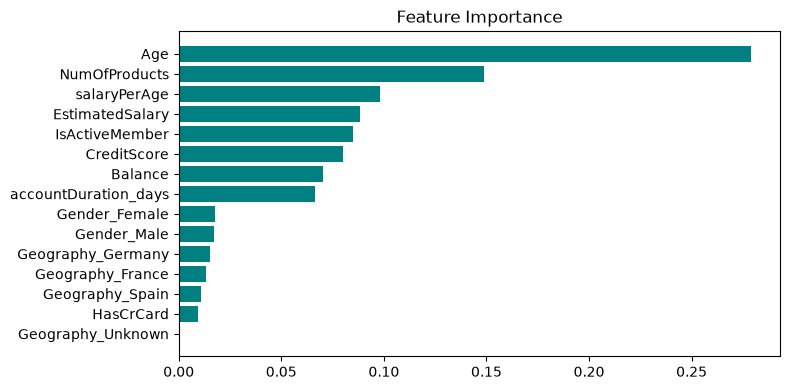

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

모델 해석 2) SHAP : 대부분 ML 모델에 적용  
\- 실제 서비스 적용 시 모델이 어떻게 작동할지를 예상할때  
\- 실제 모델 운영시 예측값 산출 근거로 사용  
\- 분석 대상 데이타 : Test Set  

- SHAP Value 산출

In [43]:
!pip install shap
import numpy as np
import shap

# ==========================================
# SHAP Value 계산
# ==========================================

explainer = shap.TreeExplainer(model)   # model 명 지정
sv = explainer.shap_values(X_test)      # X 데이터 지정

# ==========================================
# Positive Class(Class=1)의 SHAP Value 선택
# SHAP 버전에 따른 반환 형태 차이 처리
# ==========================================

if isinstance(sv, list):
    shap_values_pos = sv[1]

elif isinstance(sv, np.ndarray) and sv.ndim == 3:
    shap_values_pos = sv[:, :, 1]

else:
    shap_values_pos = sv

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Feature Importance

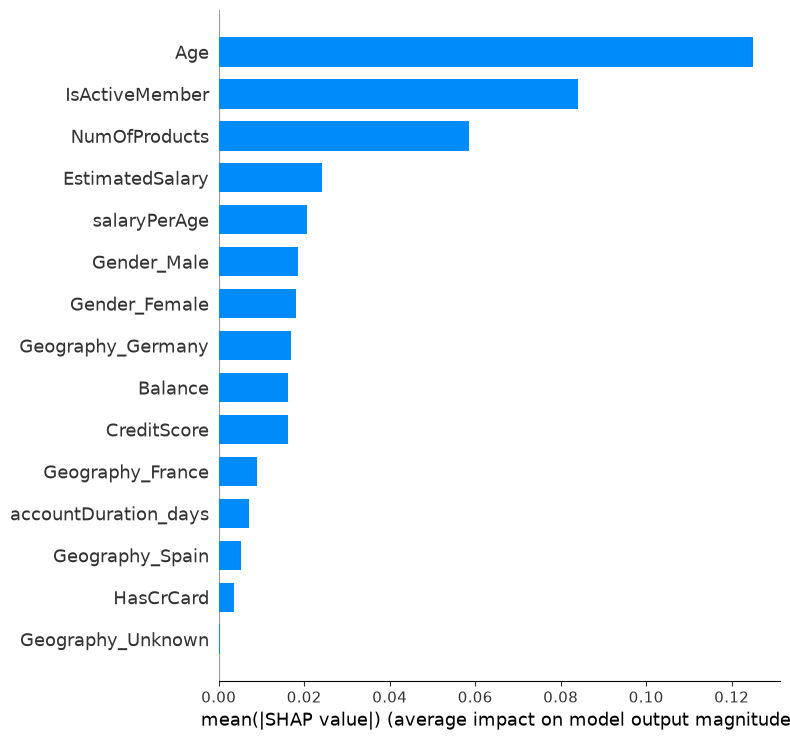

In [44]:
import matplotlib.pyplot as plt

# Importance
shap.summary_plot(shap_values_pos, X_test, plot_type="bar", max_display=30)  # 중요도 상위 Feature 갯수 지정
plt.show()

- Feature Impact

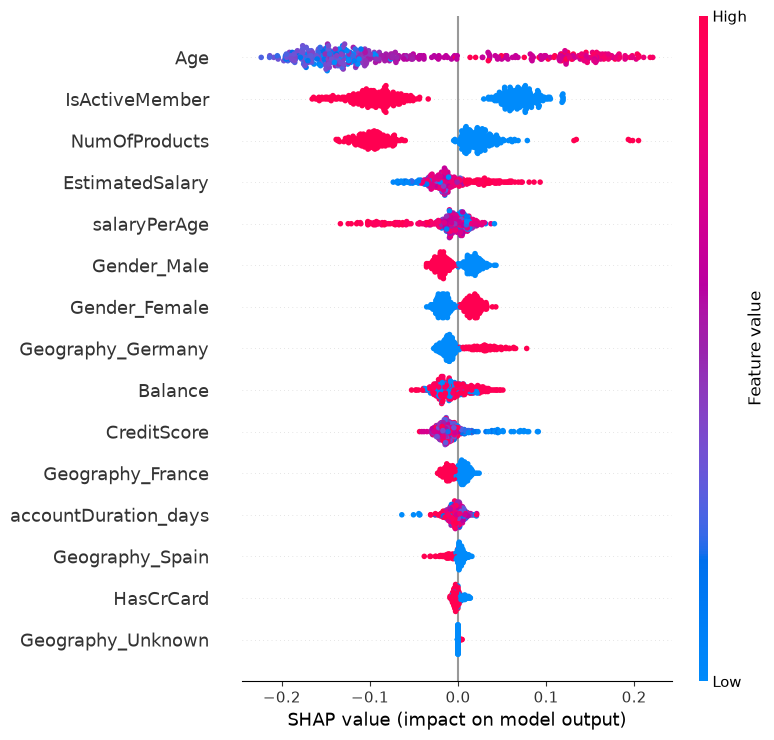

In [45]:
#  importance + direction
shap.summary_plot(shap_values_pos, X_test, max_display=30)  # 중요도 상위 Feature 갯수 지정
plt.show()

- Dependence plots

분석 대상 상위 3개 피처: ['Age', 'IsActiveMember', 'NumOfProducts']


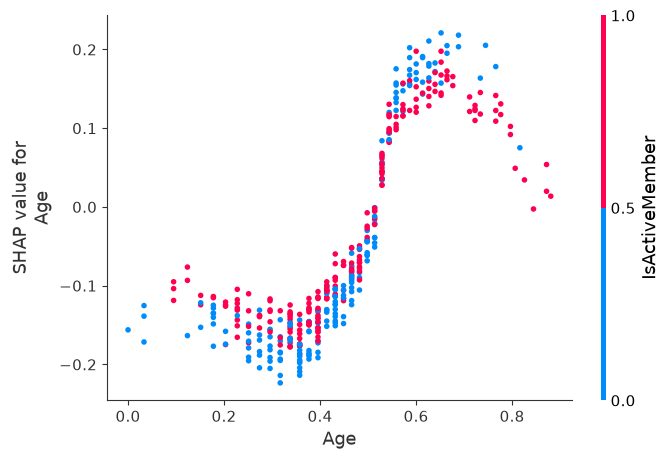

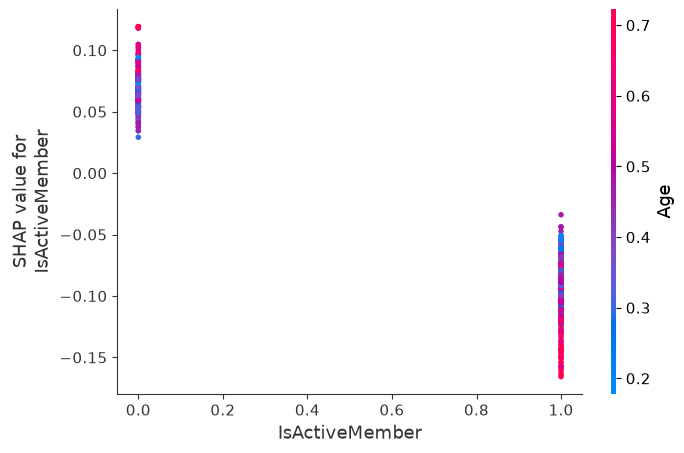

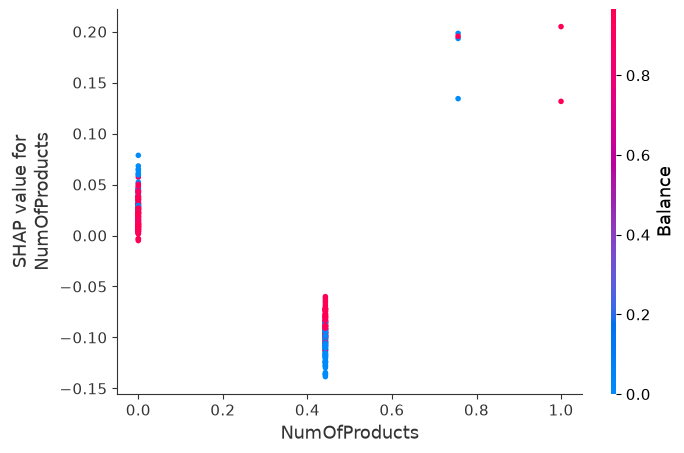

In [46]:
import numpy as np
import shap

# Feature 중요도 순위 산정
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

# 중요도 상위 Feature 추출
top_n = 3                   # 중요도 상위 Feature 갯수 지정
top_n_idx = np.argsort(mean_abs_shap)[::-1][:top_n]
top_n_features = X_test.columns[top_n_idx].tolist()

print(f"분석 대상 상위 {top_n}개 피처: {top_n_features}")

# 반복문을 통한 시각화 수행
for f_name in top_n_features:
    shap.dependence_plot(
        f_name,
        shap_values_pos,
        X_test,
        interaction_index="auto",  # 가장 상호작용이 강한 변수를 자동으로 색상 축으로 지정
        show=True
    )

- Force plot : 개별 관측치 원인 분석

In [47]:
import shap

# SHAP Plot을 위한 JavaScript 초기화
shap.initjs()

# 모델 예측의 평균적인 기준값 설정
base_value = np.atleast_1d(explainer.expected_value)

if len(base_value) > 1:
    base_value_pos = base_value[1]
else:
    base_value_pos = base_value[0]

# 분석 대상 개별 관측치 선정
i = 4                # 5번째 데이터
print(f"=== {i+1}번째 데이터의 실제 Feature 값 ===\n")
print(X_test.iloc[i])

# Force plot
shap.force_plot(
    base_value_pos,         # 모델 예측의 평균적인 기준값
    shap_values_pos[i, :],  # i번째 데이터의 Feature별 SHAP Value
    X_test.iloc[i, :]       # i번째 데이터의 실제 Feature 값
)

=== 5번째 데이터의 실제 Feature 값 ===

Age                      0.54381
NumOfProducts           0.442507
salaryPerAge             0.57779
CreditScore             0.644228
EstimatedSalary         0.667623
accountDuration_days     0.78454
Balance                      0.0
IsActiveMember               0.0
HasCrCard                    1.0
Geography_Germany          False
Geography_France           False
Geography_Spain             True
Gender_Male                False
Gender_Female               True
Geography_Unknown          False
Name: 1964, dtype: object


=> Force plot 해석 방법
- base_value : 모델 예측의 평균적인 기준값 (예: 평균 이탈 확률) *모델/SHAP 설정에 따라 확률 or Raw Score로 출력될 수 있음
- f(x) : 해당 데이터의 최종 예측값 (예: 해당 고객의 이탈 예측확률)
- 빨간색(higher) 막대 : Class 1의 예측값을 높이는 방향으로 작용한 Feature
- 파란색(lower) 막대 : Class 1의 예측값을 낮추는 방향으로 작용한 Feature
- 막대의 크기 : 영향력의 크기
- 해석 예시: 평균적인 이탈 예측확률은 약 X% 이지만, 해당 고객의 특성을 반영한 결과 이탈 예측확률은 약 X%로 낮아졌으며, 특히 Feature A와 Feature B가 이탈 가능성을 낮추는 데 크게 기여함.

### [Self-Practice]

- 실습 조건 : RandomForest 를 기본 모델로 한 Bayesian Search 결과를 이용해서 SHAP 분석하기
- 실습 시나리오
   - 시나리오 1) X_test 데이타 기준으로 Feature 중요도 상위 3개 추출하기
   - 시나리오 2) X_test 데이타 기준으로 20번째 관측치의 이탈 예측 결과를 해석하기

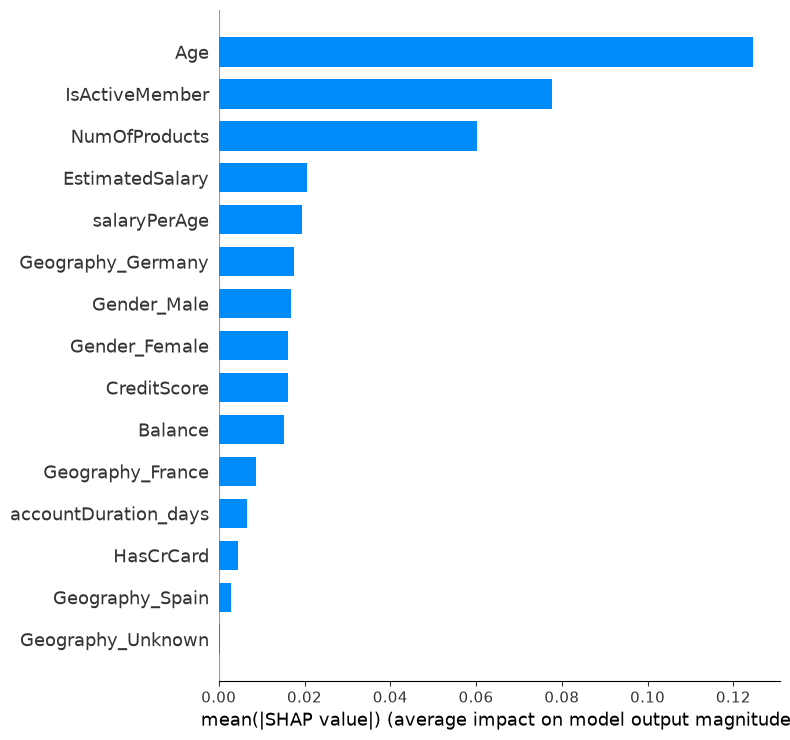

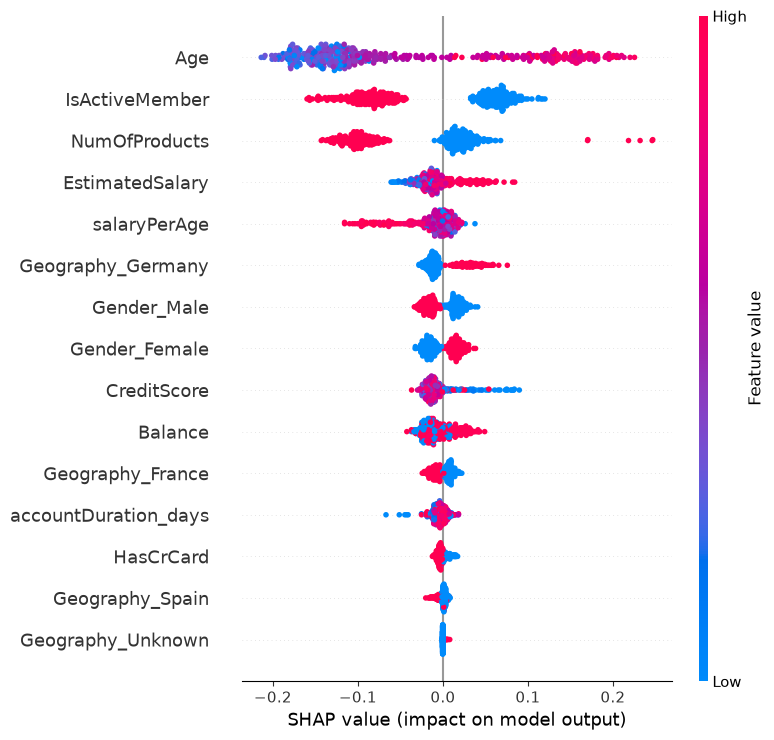

분석 대상 상위 3개 피처: ['Age', 'IsActiveMember', 'NumOfProducts']


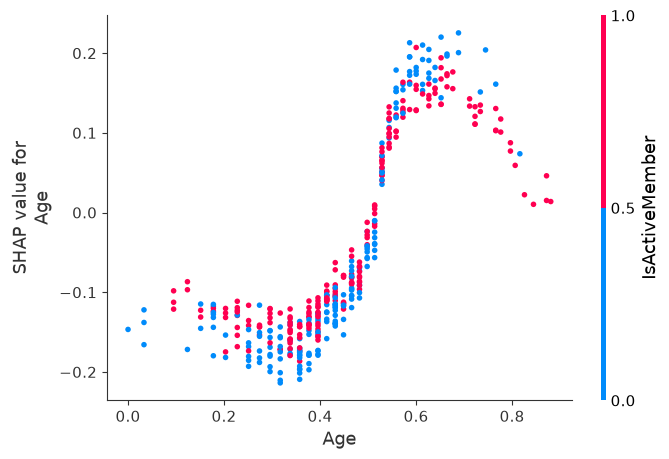

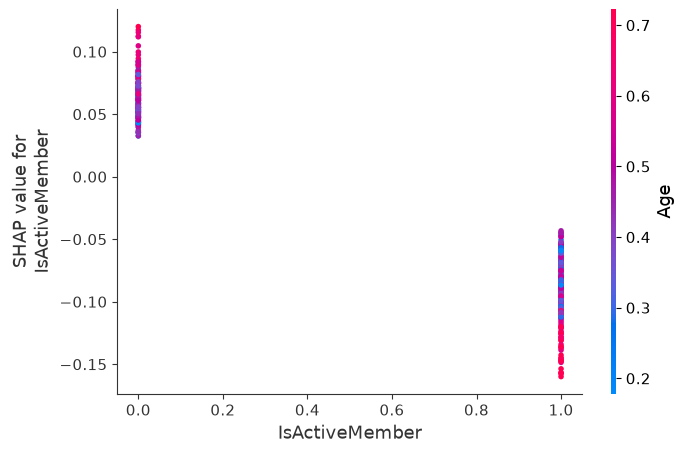

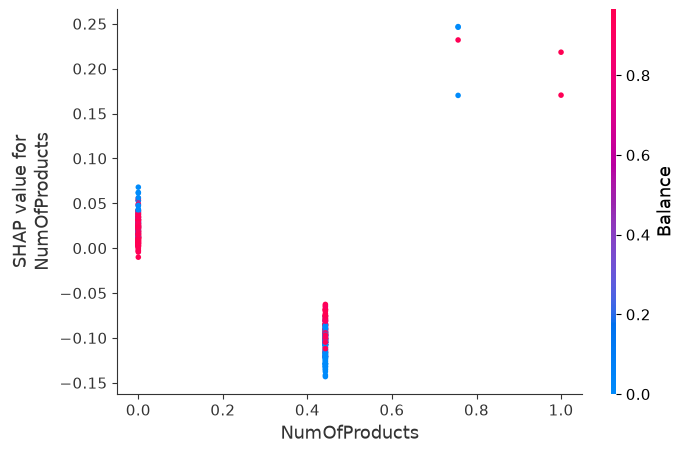

=== 20번째 데이터의 실제 Feature 값 ===

Age                     0.816122
NumOfProducts                0.0
salaryPerAge            0.814932
CreditScore             0.636931
EstimatedSalary         0.987901
accountDuration_days    0.771246
Balance                 0.950651
IsActiveMember               0.0
HasCrCard                    1.0
Geography_Germany          False
Geography_France            True
Geography_Spain            False
Gender_Male                False
Gender_Female               True
Geography_Unknown          False
Name: 123, dtype: object


In [48]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap

# OrderedDict([('max_depth', 17), ('min_samples_leaf', 4), ('min_samples_split', 19), ('n_estimators', 421)])
# 모델 생성
model = RandomForestClassifier(
    n_estimators=421,         # 트리 수
    max_depth=17,             # 트리 깊이 제한
    class_weight="balanced",  # 불균형일 때 소수 클래스에 가중치를 더 부여
    min_samples_split=19,     # 분할 최소 샘플 수
    min_samples_leaf=4,       # 리프 노드 최소 샘플 수
    random_state=42           # 난수 시드를 고정
)

model.fit(X_train, Y_train)

# ==========================================
# SHAP Value 계산
# ==========================================

explainer = shap.TreeExplainer(model)   # model 명 지정
sv = explainer.shap_values(X_test)      # X 데이터 지정

# ==========================================
# Positive Class(Class=1)의 SHAP Value 선택
# SHAP 버전에 따른 반환 형태 차이 처리
# ==========================================

if isinstance(sv, list):
    shap_values_pos = sv[1]

elif isinstance(sv, np.ndarray) and sv.ndim == 3:
    shap_values_pos = sv[:, :, 1]

else:
    shap_values_pos = sv

shap.summary_plot(shap_values_pos, X_test, plot_type="bar", max_display=30)  # 중요도 상위 Feature 갯수 지정
plt.show()


shap.summary_plot(shap_values_pos, X_test, max_display=30)  # 중요도 상위 Feature 갯수 지정
plt.show()


# Feature 중요도 순위 산정
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

# 중요도 상위 Feature 추출
top_n = 3                   # 중요도 상위 Feature 갯수 지정
top_n_idx = np.argsort(mean_abs_shap)[::-1][:top_n]
top_n_features = X_test.columns[top_n_idx].tolist()

print(f"분석 대상 상위 {top_n}개 피처: {top_n_features}")

# 반복문을 통한 시각화 수행
for f_name in top_n_features:
    shap.dependence_plot(
        f_name,
        shap_values_pos,
        X_test,
        interaction_index="auto",  # 가장 상호작용이 강한 변수를 자동으로 색상 축으로 지정
        show=True
    )


# SHAP Plot을 위한 JavaScript 초기화
shap.initjs()

# 모델 예측의 평균적인 기준값 설정
base_value = np.atleast_1d(explainer.expected_value)

if len(base_value) > 1:
    base_value_pos = base_value[1]
else:
    base_value_pos = base_value[0]

# 분석 대상 개별 관측치 선정
i = 19                # 5번째 데이터
print(f"=== {i+1}번째 데이터의 실제 Feature 값 ===\n")
print(X_test.iloc[i])

# Force plot
shap.force_plot(
    base_value_pos,         # 모델 예측의 평균적인 기준값
    shap_values_pos[i, :],  # i번째 데이터의 Feature별 SHAP Value
    X_test.iloc[i, :]       # i번째 데이터의 실제 Feature 값
)